In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sys.path.append('..')

from utils.label_creation import AutoTaggerServiceNow

# Initialize
tagger = AutoTaggerServiceNow(use_async=False, max_workers=5)

In [2]:
# Test connection
tagger.test_connection()

INFO:httpx:HTTP Request: POST https://ai-coe-openai-models-latest.openai.azure.com/openai/deployments/gpt-5/chat/completions?api-version=2025-01-01-preview "HTTP/1.1 200 OK"
INFO:utils.label_creation:✓ Connection successful!


True

## Run Predictions

Now we'll run the predictions and generate a structured CSV with:
- **number**: Ticket ID
- **text**: Concatenated text (title + description + assignment_group)
- **label**: Classification label (e.g., "(1d Broadband, 2d Fiber), 3 product status")
- **reasoning**: Explanation for the classification
- **confidence_score**: Confidence score (0-1)

Each ticket will have **3 rows** in the output (one for each of the top 3 predictions).

In [3]:
df = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/combined_data_masked.csv')

In [4]:
# concat title, description and assignment_group into one column for prediction
df['text'] = df['title'] + ' ' + df['description'] + ' ' + df['assignment_group']
prediction_df = df[["number", "text"]].copy()

In [5]:
prediction_df.head()

,number,text
0,INC0133168,Support - YouSee mail/Issue with Mit YouSee/Ca...
1,INC0133171,Support - TV/Video on demand/Streamer or Audio...
2,INC0133177,Support - TV/Other/Bland Selv After the Custom...
3,INC0133167,Support - Dawn/With Customer context/Other It ...
4,INC0133169,Support - Dawn/With Customer context/Customer ...


In [6]:
# Create a small sample to test
df_test = prediction_df.sample(n=10,random_state=42)

In [7]:
# Run predictions and create CSV with structured output
# This will create a CSV with: number, text, label, reasoning, confidence_score
# Each ticket (number) will have 3 rows (top 3 predictions)

result_df = tagger.predict_and_create_csv(
    df=df_test,
    output_path='../data/prediction_results2.csv',
    number_column='number',
    text_column='text'
)

print(f"\nTotal predictions: {len(result_df)}")
print(f"Unique tickets: {result_df['number'].nunique()}")
result_df.head(9)  # Show first 3 tickets (9 rows)

INFO:utils.label_creation:Using parallel processing...
Processing tickets:  40%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              


Total predictions: 30
Unique tickets: 10


,number,text,label,reasoning,confidence_score
0,INC0146057,Support - TV/Other/Other The Customer cannot b...,"(1g Self service, 2g YS-play), 3 Missing right...",ing: The issue is with YouSee Play’s home devi...,0.78
1,INC0146057,Support - TV/Other/Other The Customer cannot b...,"(1c TV, 2c OTT), 3 App",ing: YouSee Play is the OTT TV platform; inabi...,0.64
2,INC0146057,Support - TV/Other/Other The Customer cannot b...,"(1c TV, 2c OTT), 3 Missing rights to access","ing: From the TV product perspective, the plat...",0.55
3,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 CPR issues in Dawn",The issue is an incorrect name/CPR data in the...,0.92
4,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 Change ownership",Corrections to legal customer details (name/CP...,0.46
5,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 Tickets",If no CPR/Dawn path is applicable or it’s a ge...,0.38
6,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c COAX), 3 technical issues - Reasoni...","(1c TV, 2c COAX), 3 technical issues - ing: Vi...",0.60
7,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c Fiber), 3 technical issues - Reason...","(1c TV, 2c Fiber), 3 technical issues - ing: I...",0.30
8,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c COAX), 3 product status - Reasoning...","(1c TV, 2c COAX), 3 product status - ing: If n...",0.20


## Compare Prediction Results - Randomness Analysis

Compare the two CSV files to check for randomness and consistency between runs.

In [23]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load prediction results
result_df = pd.read_csv('../data/prediction_results.csv')

# Extract top1, top2, top3 predictions per ticket
result_df_sorted = result_df.sort_values(['number', 'confidence_score'], ascending=[True, False])
top1_df = result_df_sorted.groupby('number').nth(0).reset_index()
top2_df = result_df_sorted.groupby('number').nth(1).reset_index()
top3_df = result_df_sorted.groupby('number').nth(2).reset_index()

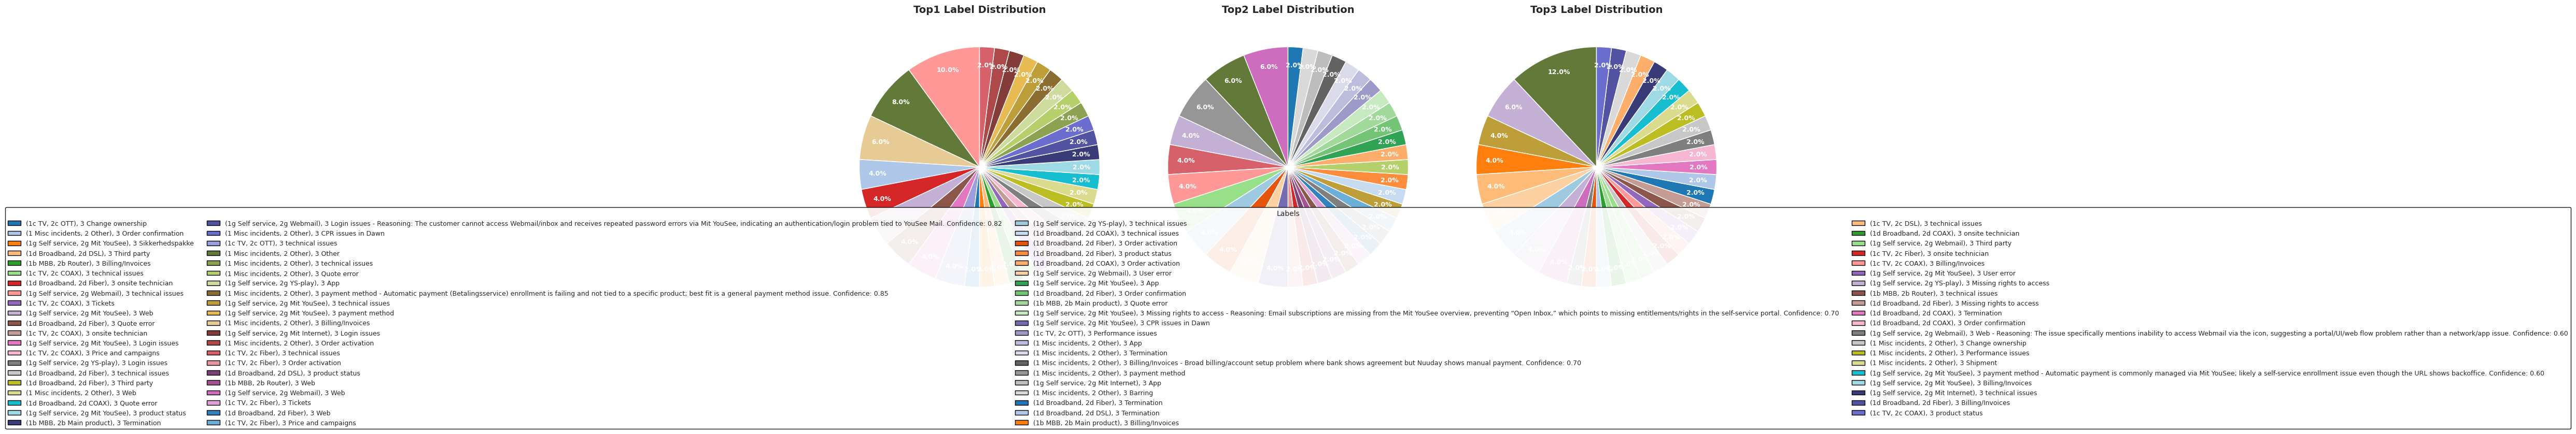


Unique labels in Top1: 35
Unique labels in Top2: 36
Unique labels in Top3: 36
Total unique labels across all predictions: 83


In [ ]:
# Label distribution for top1, top2, top3
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Collect all unique labels from top1, top2, top3
# FIX: Concatenate Series first, then get unique values
all_labels = pd.concat([
    top1_df['label'], 
    top2_df['label'], 
    top3_df['label']
]).unique()

# Assign colors for all unique labels
base_colors = list(plt.cm.tab20.colors)
# If more than 20 labels, extend with additional color maps
if len(all_labels) > 20:
    base_colors.extend(list(plt.cm.tab20b.colors))
if len(all_labels) > 40:
    base_colors.extend(list(plt.cm.tab20c.colors))

colors = [base_colors[i % len(base_colors)] for i in range(len(all_labels))]
color_map = dict(zip(all_labels, colors))

# Helper function for pie chart labels: show percent + absolute count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val})'
    return my_autopct

# Top1 label distribution
label_counts_1 = top1_df['label'].value_counts()
labels_1 = label_counts_1.index
colors_1 = [color_map[l] for l in labels_1]
wedges1, texts1, autotexts1 = axes[0].pie(
    label_counts_1.values, 
    autopct=make_autopct(label_counts_1.values), 
    startangle=90, 
    colors=colors_1,
    pctdistance=0.85
)
axes[0].set_title('Top1 Label Distribution', fontsize=14, fontweight='bold')

# Top2 label distribution
label_counts_2 = top2_df['label'].value_counts()
labels_2 = label_counts_2.index
colors_2 = [color_map[l] for l in labels_2]
wedges2, texts2, autotexts2 = axes[1].pie(
    label_counts_2.values, 
    autopct=make_autopct(label_counts_2.values), 
    startangle=90, 
    colors=colors_2,
    pctdistance=0.85
)
axes[1].set_title('Top2 Label Distribution', fontsize=14, fontweight='bold')

# Top3 label distribution
label_counts_3 = top3_df['label'].value_counts()
labels_3 = label_counts_3.index
colors_3 = [color_map[l] for l in labels_3]
wedges3, texts3, autotexts3 = axes[2].pie(
    label_counts_3.values, 
    autopct=make_autopct(label_counts_3.values), 
    startangle=90, 
    colors=colors_3,
    pctdistance=0.85
)
axes[2].set_title('Top3 Label Distribution', fontsize=14, fontweight='bold')

# Make percentage text more readable
for autotext in autotexts1 + autotexts2 + autotexts3:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

# Equal aspect ratio for all pie charts
for ax in axes:
    ax.set_aspect('equal')

# Create custom legend handles with matching colors
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color_map[label], edgecolor='black', label=label) 
                  for label in all_labels]

# One legend for all unique labels, centered below all charts
fig.legend(
    handles=legend_handles,
    labels=all_labels,
    title='Labels',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    fontsize=9,
    ncol=min(4, len(all_labels)),
    frameon=True,
    framealpha=0.9,
    edgecolor='black'
)

plt.subplots_adjust(bottom=0.32, top=0.85)
plt.tight_layout()
plt.show()

print(f"\nUnique labels in Top1: {top1_df['label'].nunique()}")
print(f"Unique labels in Top2: {top2_df['label'].nunique()}")
print(f"Unique labels in Top3: {top3_df['label'].nunique()}")
print(f"Total unique labels across all predictions: {len(all_labels)}")

/tmp/ipykernel_13187/2112351737.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(box_data, labels=['Top1', 'Top2', 'Top3'], patch_artist=True,


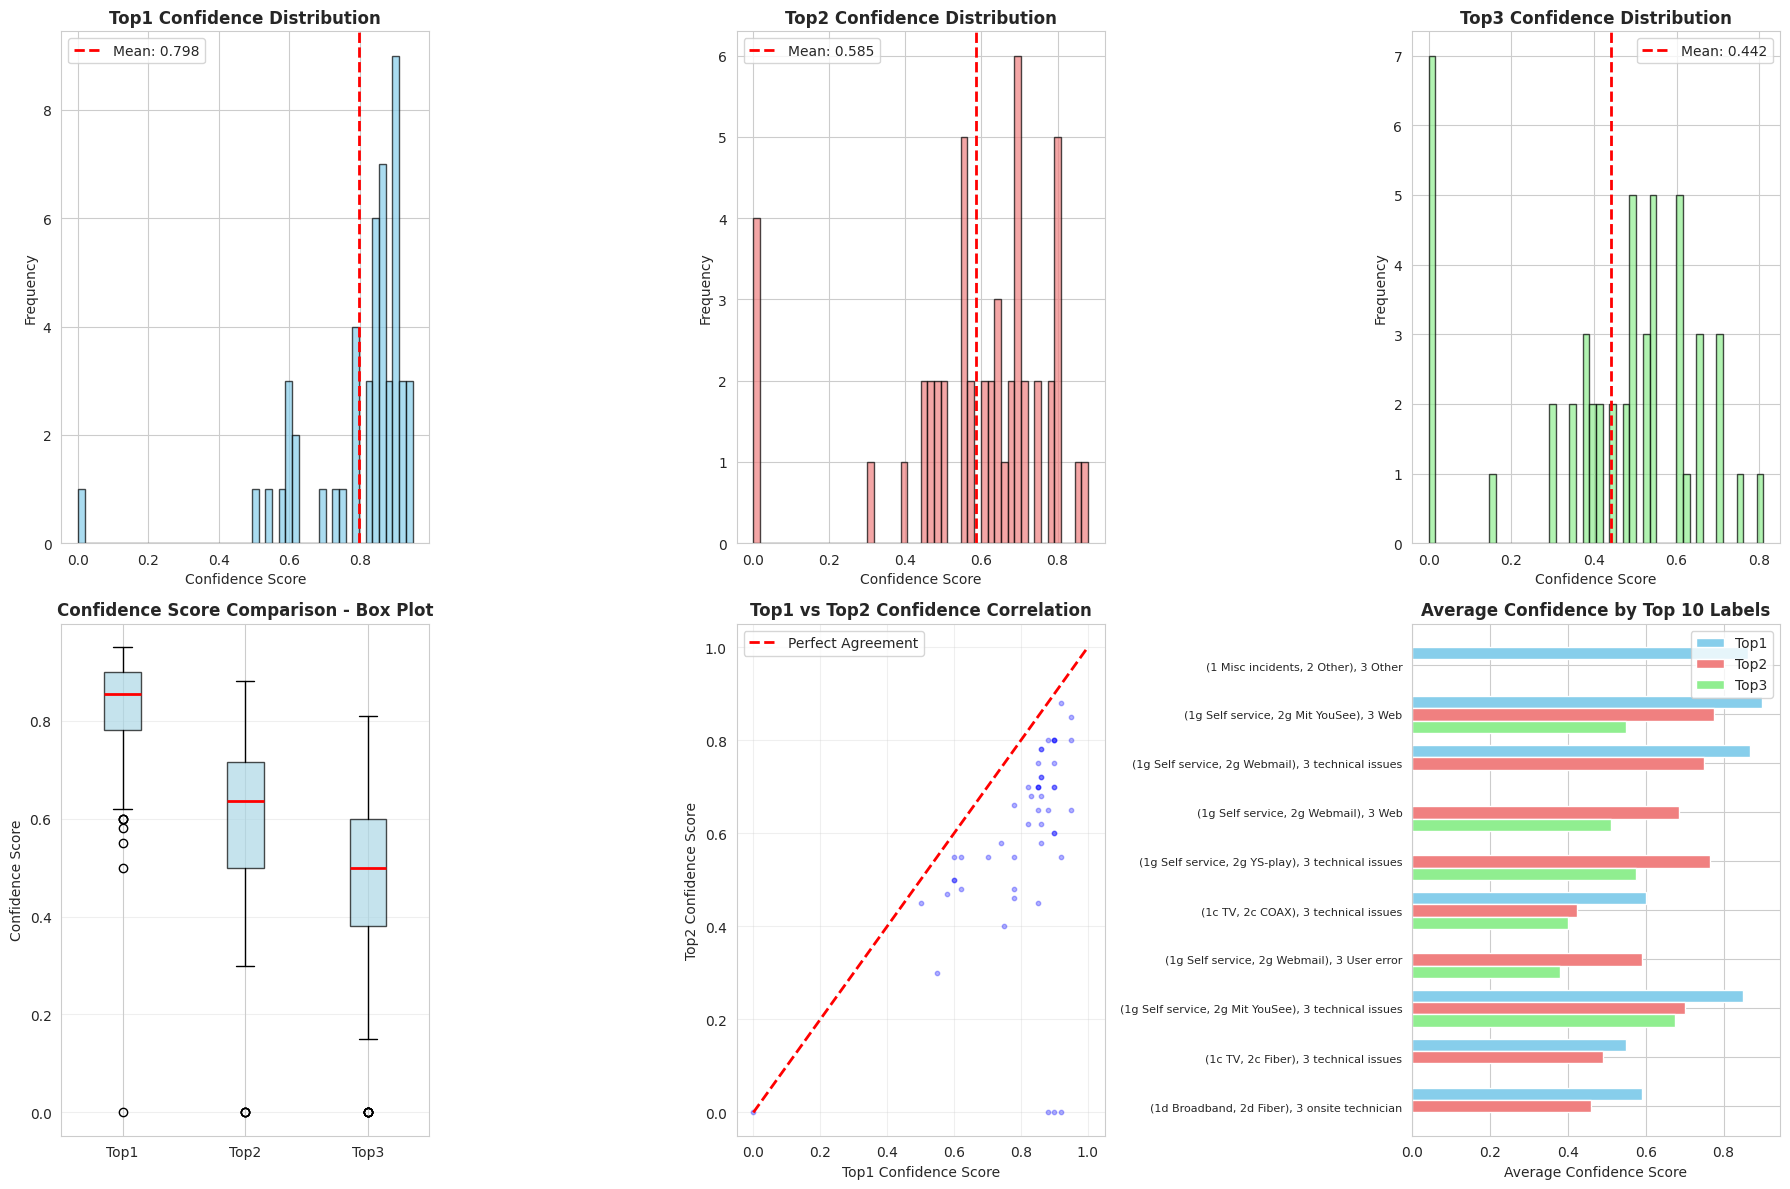

In [25]:
# Confidence score analysis for top1, top2, top3
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top1 confidence distribution
axes[0, 0].hist(top1_df['confidence_score'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(top1_df['confidence_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {top1_df["confidence_score"].mean():.3f}')
axes[0, 0].set_xlabel('Confidence Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Top1 Confidence Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# Top2 confidence distribution
axes[0, 1].hist(top2_df['confidence_score'], bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(top2_df['confidence_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {top2_df["confidence_score"].mean():.3f}')
axes[0, 1].set_xlabel('Confidence Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Top2 Confidence Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# Top3 confidence distribution
axes[0, 2].hist(top3_df['confidence_score'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(top3_df['confidence_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {top3_df["confidence_score"].mean():.3f}')
axes[0, 2].set_xlabel('Confidence Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Top3 Confidence Distribution', fontsize=12, fontweight='bold')
axes[0, 2].legend()

# Box plot comparison
box_data = [top1_df['confidence_score'], top2_df['confidence_score'], top3_df['confidence_score']]
axes[1, 0].boxplot(box_data, labels=['Top1', 'Top2', 'Top3'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Confidence Score')
axes[1, 0].set_title('Confidence Score Comparison - Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Scatter plot: Top1 vs Top2 confidence
axes[1, 1].scatter(top1_df['confidence_score'], top2_df['confidence_score'], alpha=0.3, s=10, color='blue')
axes[1, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Agreement')
axes[1, 1].set_xlabel('Top1 Confidence Score')
axes[1, 1].set_ylabel('Top2 Confidence Score')
axes[1, 1].set_title('Top1 vs Top2 Confidence Correlation', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Average confidence by label (top 10 labels across all)
all_labels = result_df['label'].value_counts().head(10).index
avg_conf_top1 = top1_df[top1_df['label'].isin(all_labels)].groupby('label')['confidence_score'].mean().reindex(all_labels)
avg_conf_top2 = top2_df[top2_df['label'].isin(all_labels)].groupby('label')['confidence_score'].mean().reindex(all_labels)
avg_conf_top3 = top3_df[top3_df['label'].isin(all_labels)].groupby('label')['confidence_score'].mean().reindex(all_labels)

x = np.arange(len(all_labels))
width = 0.25

axes[1, 2].barh(x - width, avg_conf_top1.values, width, label='Top1', color='skyblue')
axes[1, 2].barh(x, avg_conf_top2.values, width, label='Top2', color='lightcoral')
axes[1, 2].barh(x + width, avg_conf_top3.values, width, label='Top3', color='lightgreen')
axes[1, 2].set_yticks(x)
axes[1, 2].set_yticklabels(all_labels, fontsize=8)
axes[1, 2].set_xlabel('Average Confidence Score')
axes[1, 2].set_title('Average Confidence by Top 10 Labels', fontsize=12, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()